# Chain

We built a simple graph with nodes, normal edges and conditional edges.

## Goals

Now, let's build up to a simple chain that combines 4 concepts

- Using chat messages as our graph state
- Using chat models in graph nodes
- Binding tools to our chat model
- Executing tool calls in graph nodes

## Messages

In [2]:
from pprint import pprint
from langchain_core.messages import HumanMessage, AIMessage

messages = [AIMessage(content=f'So you said you were researching ocean mammals?', name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right", name="Saket"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Saket"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Saket

Yes, that's right
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Saket

I want to learn about the best place to see Orcas in the US.


## Chat Models

In [5]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("ANTHROPIC_API_KEY")

In [6]:
from langchain_anthropic import ChatAnthropic
llm = ChatAnthropic(model="claude-haiku-4-5")
result = llm.invoke(messages)
type(result)

langchain_core.messages.ai.AIMessage

In [7]:
result

AIMessage(content="# Best Places to See Orcas in the US\n\nThe Pacific Northwest is widely considered the best region for orca watching in the United States. Here are the top locations:\n\n## **1. San Juan Islands, Washington** (Top choice)\n- Located between Seattle and Vancouver, BC\n- Home to resident orca pods (J, K, and L pods)\n- Best season: June through September\n- Accessible via boat tours from Friday Harbor and Anacortes\n\n## **2. Monterey Bay, California**\n- Good for seeing transient (Bigg's) orcas\n- Best season: Fall and winter months\n- Often combined with whale watching for other species\n\n## **3. Puget Sound, Washington**\n- Year-round orca presence\n- More accessible than San Juan Islands\n- Offers excellent viewing from land and boat tours\n\n## **4. Alaska (Southeast)**\n- Large orca populations\n- Less crowded than San Juan Islands\n- Best season: Summer months\n- Requires more travel but offers excellent sightings\n\n## **Key Tips:**\n- **Peak season**: June-Se

In [8]:
result.response_metadata

{'id': 'msg_017HYK8ymp9qAis8t6KGFvWp',
 'container': None,
 'model': 'claude-haiku-4-5-20251001',
 'stop_details': None,
 'stop_reason': 'end_turn',
 'stop_sequence': None,
 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0,
   'ephemeral_5m_input_tokens': 0},
  'cache_creation_input_tokens': 0,
  'cache_read_input_tokens': 0,
  'inference_geo': 'not_available',
  'input_tokens': 71,
  'output_tokens': 307,
  'server_tool_use': None,
  'service_tier': 'standard'},
 'model_name': 'claude-haiku-4-5-20251001',
 'model_provider': 'anthropic'}

## Tools

In [9]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int    
    """
    return a * b

llm_with_tools = llm.bind_tools([multiply])

In [10]:
tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3?", name="Saket")])

In [11]:
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'toolu_01GxHw84sqcJMxzJVtXMD3Zj',
  'type': 'tool_call'}]

## Using messages as State

In [12]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages: list[AnyMessage]

## Reducers

In [13]:
from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [14]:
from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built
    pass

In [15]:
# Initial state
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Saket")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# test
add_messages(initial_messages, new_message)


[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='8f730d8d-cb13-4a9f-a3cd-917f246000c7', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Saket', id='7655c30e-c4a5-4267-bd0f-4a777377aa52'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='640f7b7e-36e1-4d52-b9c4-87c9e797122c', tool_calls=[], invalid_tool_calls=[])]

## Our graph

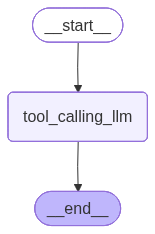

In [16]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# Build Graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [17]:
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hello! 👋 How can I help you today? I have access to a multiplication function if you need to multiply two numbers together, or I'm happy to help with other questions or tasks!


In [18]:
messages = graph.invoke({"messages": HumanMessage(content="Multiple 4 and 5")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiple 4 and 5
================================== Ai Message ==================================

[{'id': 'toolu_013qPkLaFnUwitimcCLzNYi5', 'caller': {'type': 'direct'}, 'input': {'a': 4, 'b': 5}, 'name': 'multiply', 'type': 'tool_use'}]
Tool Calls:
  multiply (toolu_013qPkLaFnUwitimcCLzNYi5)
 Call ID: toolu_013qPkLaFnUwitimcCLzNYi5
  Args:
    a: 4
    b: 5
